In [1]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------------ --------------------------- 3.7/12.1 MB 21.1 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 24.3 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 25.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 45.7 MB/s eta 0:00:00

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ------------------------ --------------- 3/5 [cmdstanpy]
   -------------

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
print("All libraries loaded successfully")

All libraries loaded successfully


# Northwind Apparel Co. — Demand Forecasting Analysis
## Multi-Model Time Series Forecast | Jan 2023 – Dec 2025 + 12-Month Forward Projection

**Analyst:** Joel Diaz  
**Date:** May 2026  
**Dataset:** Synthetic supply chain data (~50,000 orders, 3 years)  
**Objective:** Compare forecasting methods (Moving Average, Exponential Smoothing, Prophet) 
and generate a 12-month demand forecast with confidence intervals to support 
Northwind's 2026 capacity planning decisions.

---

## Section 1: Setup & Data Loading

In [7]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Exponential smooth
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Prophet Forecasting
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# Accuracy metrics
from sklearn.metrics import mean_absolute_percentage_error

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {pd.__version__}")

All libraries imported successfully.
Pandas version: 2.2.3
NumPy version: 2.2.3


In [8]:
# Load orders dataset
orders = pd.read_csv(r'data/orders.csv')

# Preview data
print("Shape:", orders.shape)
print("\nColumns:", orders.columns.tolist())
print("\nFirst 3 rows:")
orders.head(3)

Shape: (50000, 12)

Columns: ['order_id', 'customer_id', 'order_date', 'ship_date', 'delivery_date', 'promised_delivery_date', 'shipping_mode', 'shipping_cost', 'dc_id', 'order_status', 'on_time_delivery', 'order_total']

First 3 rows:


,order_id,customer_id,order_date,ship_date,delivery_date,promised_delivery_date,shipping_mode,shipping_cost,dc_id,order_status,on_time_delivery,order_total
0,100001,2961,2023-01-01,2023-01-01,2023-01-07,2023-01-07,Standard,8.99,2,Delivered,1,79.78
1,100002,957,2023-01-01,2023-01-02,2023-01-03,2023-01-05,Express,12.99,2,Returned,0,114.89
2,100003,2698,2023-01-01,2023-01-02,2023-01-12,2023-01-07,Standard,9.99,4,Delivered,0,126.72


In [9]:
# Convert order_date to datetime type
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Filter to delivered orders only (same logic as SQL Q4)
delivered = orders[orders['order_status'] == 'Delivered'].copy()

# Aggregate to monthly revenue
monthly = (
    delivered
    .groupby(pd.Grouper(key='order_date', freq='MS'))  # MS = Month Start
    .agg(
        total_revenue=('order_total', 'sum'),
        order_count=('order_id', 'count'),
        avg_order_value=('order_total', 'mean')
    )
    .reset_index()
)

# Rename for clarity
monthly.columns = ['date', 'total_revenue', 'order_count', 'avg_order_value']

print(f"Monthly time series: {len(monthly)} months")
print(f"Date range: {monthly['date'].min()} to {monthly['date'].max()}")
print(f"\nRevenue range: ${monthly['total_revenue'].min():,.0f} to ${monthly['total_revenue'].max():,.0f}")
print(f"Avg monthly revenue: ${monthly['total_revenue'].mean():,.0f}")
print("\nFirst 6 months:")
monthly.head(6)

Monthly time series: 36 months
Date range: 2023-01-01 00:00:00 to 2025-12-01 00:00:00

Revenue range: $90,159 to $353,478
Avg monthly revenue: $184,548

First 6 months:


,date,total_revenue,order_count,avg_order_value
0,2023-01-01,104516.58,744,140.48
1,2023-02-01,92263.43,668,138.12
2,2023-03-01,143632.13,1022,140.54
3,2023-04-01,165046.77,1160,142.28
4,2023-05-01,161485.79,1162,138.97
5,2023-06-01,162069.25,1145,141.55


## Section 2: Exploratory Data Analysis (EDA)

Before building forecasting models, we examine the time series for:
- **Trend:** Is revenue growing, declining, or flat over 3 years?
- **Seasonality:** Are there recurring patterns within each year?
- **Volatility:** Are there unusual spikes or anomalies?

Understanding these patterns determines which forecasting models are appropriate.

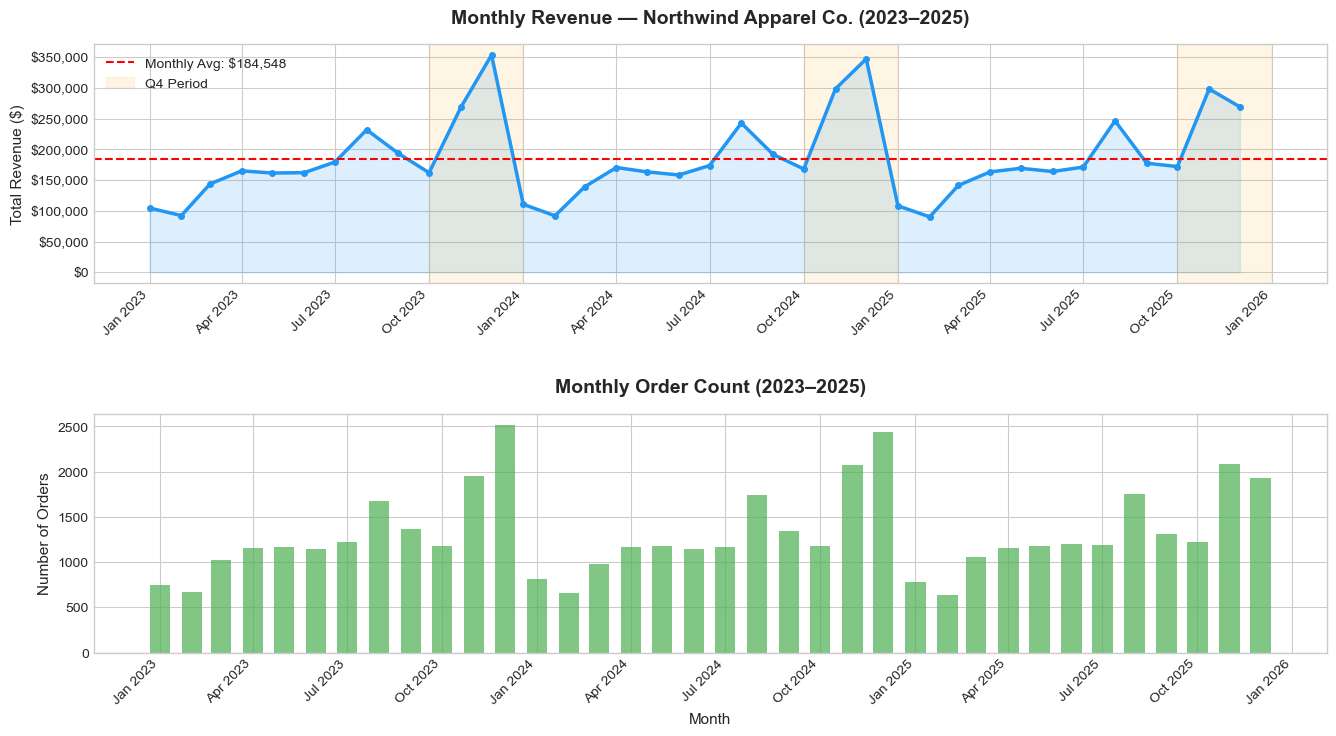

Chart saved as eda_revenue_overview.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Top chart: Revenue ---
axes[0].plot(monthly['date'], monthly['total_revenue'], 
             color='#2196F3', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(monthly['date'], monthly['total_revenue'], 
                      alpha=0.15, color='#2196F3')

# Add average reference line
avg_rev = monthly['total_revenue'].mean()
axes[0].axhline(y=avg_rev, color='red', linestyle='--', 
                linewidth=1.5, label=f'Monthly Avg: ${avg_rev:,.0f}')

# Shade Q4 periods to highlight seasonality
for year in [2023, 2024, 2025]:
    axes[0].axvspan(pd.Timestamp(f'{year}-10-01'), 
                    pd.Timestamp(f'{year}-12-31'),
                    alpha=0.1, color='orange', 
                    label='Q4 Period' if year == 2023 else '')

axes[0].set_title('Monthly Revenue — Northwind Apparel Co. (2023–2025)', 
                   fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Total Revenue ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend(fontsize=10)
axes[0].set_xlabel('')

# --- Bottom chart: Order count ---
axes[1].bar(monthly['date'], monthly['order_count'], 
            color='#4CAF50', alpha=0.7, width=20)
axes[1].set_title('Monthly Order Count (2023–2025)', 
                   fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_xlabel('Month', fontsize=11)

# Format x-axis dates on both charts
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.savefig('eda_revenue_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as eda_revenue_overview.png")

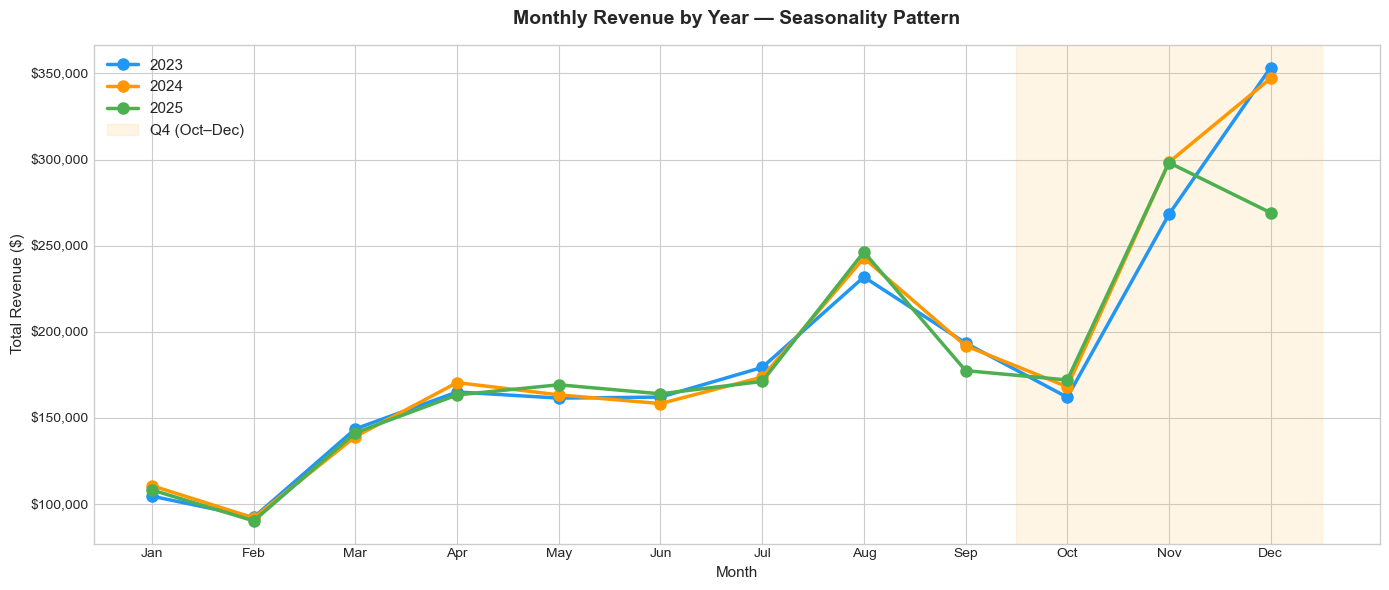

Chart saved as eda_seasonality_by_year.png


In [11]:
# Add month and year columns for analysis
monthly['month'] = monthly['date'].dt.month
monthly['year'] = monthly['date'].dt.year
monthly['month_name'] = monthly['date'].dt.strftime('%b')

# Month order for x-axis
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 6))

# Plot each year as a separate line to show year-over-year pattern
colors = {'2023': '#2196F3', '2024': '#FF9800', '2025': '#4CAF50'}
for year in [2023, 2024, 2025]:
    year_data = monthly[monthly['year'] == year].copy()
    year_data = year_data.sort_values('month')
    ax.plot(year_data['month_name'], year_data['total_revenue'],
            marker='o', linewidth=2.5, markersize=8,
            label=str(year), color=colors[str(year)])

# Shade Q4
ax.axvspan(8.5, 11.5, alpha=0.1, color='orange', label='Q4 (Oct–Dec)')

ax.set_title('Monthly Revenue by Year — Seasonality Pattern', 
              fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=11)

# Set x-axis to month names in order
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)

plt.tight_layout()
plt.savefig('eda_seasonality_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as eda_seasonality_by_year.png")

In [12]:
# Quantify the seasonality story
q4_months = monthly[monthly['month'].isin([10, 11, 12])]
non_q4_months = monthly[~monthly['month'].isin([10, 11, 12])]

q4_avg = q4_months['total_revenue'].mean()
non_q4_avg = non_q4_months['total_revenue'].mean()
seasonality_ratio = q4_avg / non_q4_avg

jan_feb_avg = monthly[monthly['month'].isin([1, 2])]['total_revenue'].mean()
peak_month_avg = monthly[monthly['month'].isin([11, 12])]['total_revenue'].mean()
peak_to_trough = peak_month_avg / jan_feb_avg

# Year over year growth
rev_2023 = monthly[monthly['year'] == 2023]['total_revenue'].sum()
rev_2024 = monthly[monthly['year'] == 2024]['total_revenue'].sum()
rev_2025 = monthly[monthly['year'] == 2025]['total_revenue'].sum()

yoy_2324 = (rev_2024 - rev_2023) / rev_2023 * 100
yoy_2425 = (rev_2025 - rev_2024) / rev_2024 * 100

print("=" * 55)
print("  NORTHWIND APPAREL — EDA SUMMARY")
print("=" * 55)
print(f"\n  REVENUE OVERVIEW")
print(f"  Total 3-Year Revenue:     ${monthly['total_revenue'].sum():>12,.0f}")
print(f"  Avg Monthly Revenue:      ${monthly['total_revenue'].mean():>12,.0f}")
print(f"  Peak Month Revenue:       ${monthly['total_revenue'].max():>12,.0f}")
print(f"  Trough Month Revenue:     ${monthly['total_revenue'].min():>12,.0f}")

print(f"\n  YEAR-OVER-YEAR GROWTH")
print(f"  2023 Annual Revenue:      ${rev_2023:>12,.0f}")
print(f"  2024 Annual Revenue:      ${rev_2024:>12,.0f}  ({yoy_2324:+.1f}% YoY)")
print(f"  2025 Annual Revenue:      ${rev_2025:>12,.0f}  ({yoy_2425:+.1f}% YoY)")

print(f"\n  SEASONALITY")
print(f"  Q4 Avg Monthly Revenue:   ${q4_avg:>12,.0f}")
print(f"  Non-Q4 Avg Revenue:       ${non_q4_avg:>12,.0f}")
print(f"  Q4 Seasonality Ratio:     {seasonality_ratio:>11.2f}x")
print(f"  Peak-to-Trough Ratio:     {peak_to_trough:>11.2f}x")
print("=" * 55)

  NORTHWIND APPAREL — EDA SUMMARY

  REVENUE OVERVIEW
  Total 3-Year Revenue:     $   6,643,712
  Avg Monthly Revenue:      $     184,548
  Peak Month Revenue:       $     353,478
  Trough Month Revenue:     $      90,159

  YEAR-OVER-YEAR GROWTH
  2023 Annual Revenue:      $   2,217,278
  2024 Annual Revenue:      $   2,255,934  (+1.7% YoY)
  2025 Annual Revenue:      $   2,170,500  (-3.8% YoY)

  SEASONALITY
  Q4 Avg Monthly Revenue:   $     259,646
  Non-Q4 Avg Revenue:       $     159,515
  Q4 Seasonality Ratio:            1.63x
  Peak-to-Trough Ratio:            3.07x


## Section 3: Time Series Decomposition

Decomposition separates the revenue signal into three components:
- **Trend:** The underlying direction of revenue over 3 years
- **Seasonality:** Recurring annual patterns (Q4 holiday spike, Jan/Feb trough)
- **Residual:** Random variation after trend and seasonality are removed

We use **multiplicative decomposition** because the seasonal swings grow proportionally 
with revenue level — a characteristic of most retail time series.

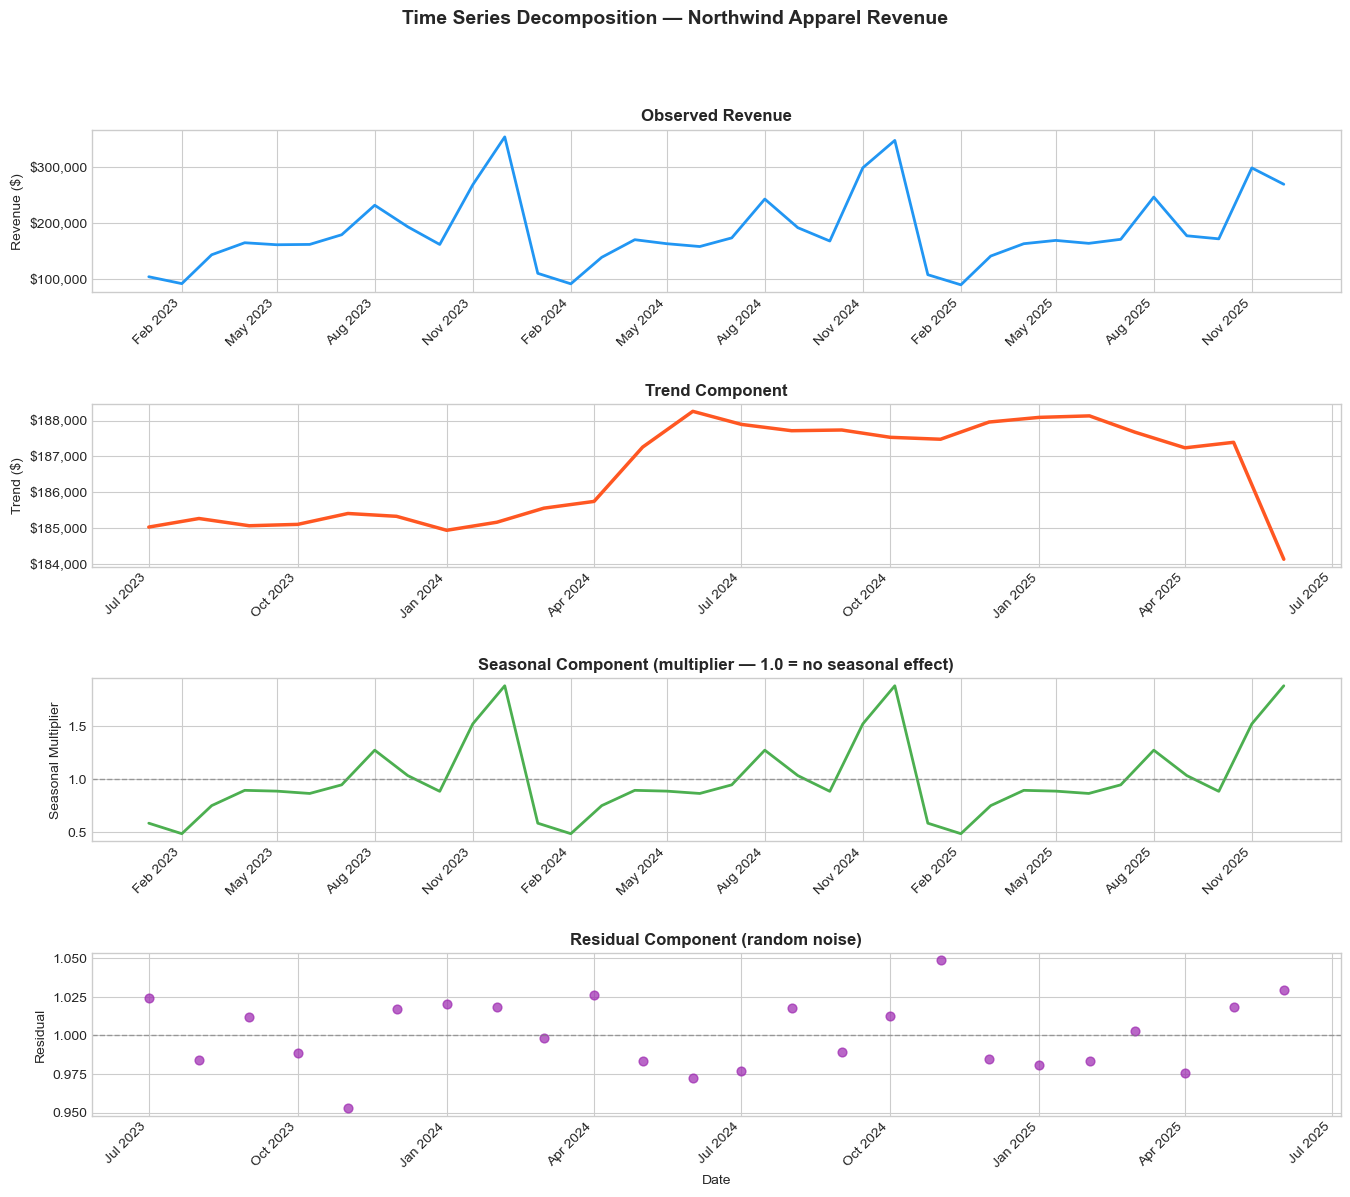

Decomposition chart saved


In [13]:
# Set date as index for statsmodels
monthly_indexed = monthly.set_index('date')['total_revenue']

# Multiplicative decomposition with period=12 (annual seasonality)
decomposition = seasonal_decompose(
    monthly_indexed,
    model='multiplicative',  # seasonal swings scale with revenue level
    period=12                # 12 months = one full seasonal cycle
)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot all four components
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# --- Observed ---
axes[0].plot(monthly_indexed.index, monthly_indexed.values,
             color='#2196F3', linewidth=2)
axes[0].set_title('Observed Revenue', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].set_ylabel('Revenue ($)')

# --- Trend ---
axes[1].plot(trend.index, trend.values,
             color='#FF5722', linewidth=2.5)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1].set_ylabel('Trend ($)')

# --- Seasonality ---
axes[2].plot(seasonal.index, seasonal.values,
             color='#4CAF50', linewidth=2)
axes[2].axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Seasonal Component (multiplier — 1.0 = no seasonal effect)',
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal Multiplier')

# --- Residual ---
axes[3].scatter(residual.index, residual.values,
                color='#9C27B0', alpha=0.7, s=40)
axes[3].axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[3].set_title('Residual Component (random noise)',
                   fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

# Format x-axis on all panels
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Time Series Decomposition — Northwind Apparel Revenue',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decomposition chart saved")

In [14]:
# Get the average seasonal multiplier for each calendar month
seasonal_factors = (
    seasonal
    .groupby(seasonal.index.month)
    .mean()
    .reset_index()
)
seasonal_factors.columns = ['month', 'seasonal_multiplier']
seasonal_factors['month_name'] = pd.to_datetime(
    seasonal_factors['month'], format='%m').dt.strftime('%B')
seasonal_factors['pct_above_below_avg'] = (
    (seasonal_factors['seasonal_multiplier'] - 1) * 100).round(1)

# Sort by multiplier for easy reading
seasonal_factors_sorted = seasonal_factors.sort_values(
    'seasonal_multiplier', ascending=False)

print("=" * 52)
print("  SEASONAL MULTIPLIERS BY MONTH")
print("  (>1.0 = above average | <1.0 = below average)")
print("=" * 52)
for _, row in seasonal_factors_sorted.iterrows():
    bar = "▲" if row['seasonal_multiplier'] > 1 else "▼"
    print(f"  {row['month_name']:<12} {bar}  "
          f"{row['seasonal_multiplier']:.3f}x  "
          f"({row['pct_above_below_avg']:+.1f}%)")
print("=" * 52)

# Identify peak and trough months
peak = seasonal_factors_sorted.iloc[0]
trough = seasonal_factors_sorted.iloc[-1]
print(f"\n  Peak month:   {peak['month_name']} "
      f"({peak['pct_above_below_avg']:+.1f}% above avg)")
print(f"  Trough month: {trough['month_name']} "
      f"({trough['pct_above_below_avg']:+.1f}% below avg)")
print(f"\n  Operational implication: Northwind needs "
      f"{peak['seasonal_multiplier']/trough['seasonal_multiplier']:.1f}x "
      f"the capacity in {peak['month_name']} vs {trough['month_name']}")

  SEASONAL MULTIPLIERS BY MONTH
  (>1.0 = above average | <1.0 = below average)
  December     ▲  1.876x  (+87.6%)
  November     ▲  1.518x  (+51.8%)
  August       ▲  1.271x  (+27.1%)
  September    ▲  1.033x  (+3.3%)
  July         ▼  0.946x  (-5.4%)
  April        ▼  0.894x  (-10.6%)
  May          ▼  0.887x  (-11.3%)
  October      ▼  0.885x  (-11.5%)
  June         ▼  0.865x  (-13.5%)
  March        ▼  0.751x  (-24.9%)
  January      ▼  0.586x  (-41.4%)
  February     ▼  0.487x  (-51.3%)

  Peak month:   December (+87.6% above avg)
  Trough month: February (-51.3% below avg)

  Operational implication: Northwind needs 3.8x the capacity in December vs February


## Section 4: Model 1 — Simple Moving Average (Baseline)

Before building sophisticated models, we establish a **baseline forecast** using a 
3-month Simple Moving Average (SMA). 

A baseline serves two purposes:
1. **Sanity check** — if our advanced models can't beat a simple average, something is wrong
2. **Benchmark** — all model accuracy scores are compared against this baseline

**How SMA works:** Each forecast point = the average of the previous N months.
A 3-month SMA means: "My best guess for next month is the average of the last 3 months."

**Limitation:** SMA cannot capture trend or seasonality — it just smooths noise.
This is why it's a baseline, not a final model.

In [15]:
# ── Simple Moving Average ──────────────────────────────────────────
WINDOW = 3   # 3-month rolling average

# Create a working copy with the SMA column
sma_df = monthly[['date', 'total_revenue']].copy()
sma_df['sma_forecast'] = (
    sma_df['total_revenue']
    .shift(1)                    # shift so we forecast NEXT month, not current
    .rolling(window=WINDOW)
    .mean()
)

# Drop the NaN rows created by the rolling window
sma_valid = sma_df.dropna().copy()

# ── Accuracy: MAPE ─────────────────────────────────────────────────
# MAPE = Mean Absolute Percentage Error
# "On average, my forecast is X% away from the actual value"
# Lower is better. <10% is good. <5% is excellent.
sma_mape = mean_absolute_percentage_error(
    sma_valid['total_revenue'],
    sma_valid['sma_forecast']
) * 100

print(f"Simple Moving Average (3-month window)")
print(f"{'─' * 40}")
print(f"  Training points used: {len(sma_valid)}")
print(f"  MAPE: {sma_mape:.2f}%")
print(f"  Interpretation: On average, the SMA forecast")
print(f"  is {sma_mape:.1f}% away from actual revenue")
print(f"\n  (This is our BASELINE to beat)")

Simple Moving Average (3-month window)
────────────────────────────────────────
  Training points used: 33
  MAPE: 37.11%
  Interpretation: On average, the SMA forecast
  is 37.1% away from actual revenue

  (This is our BASELINE to beat)


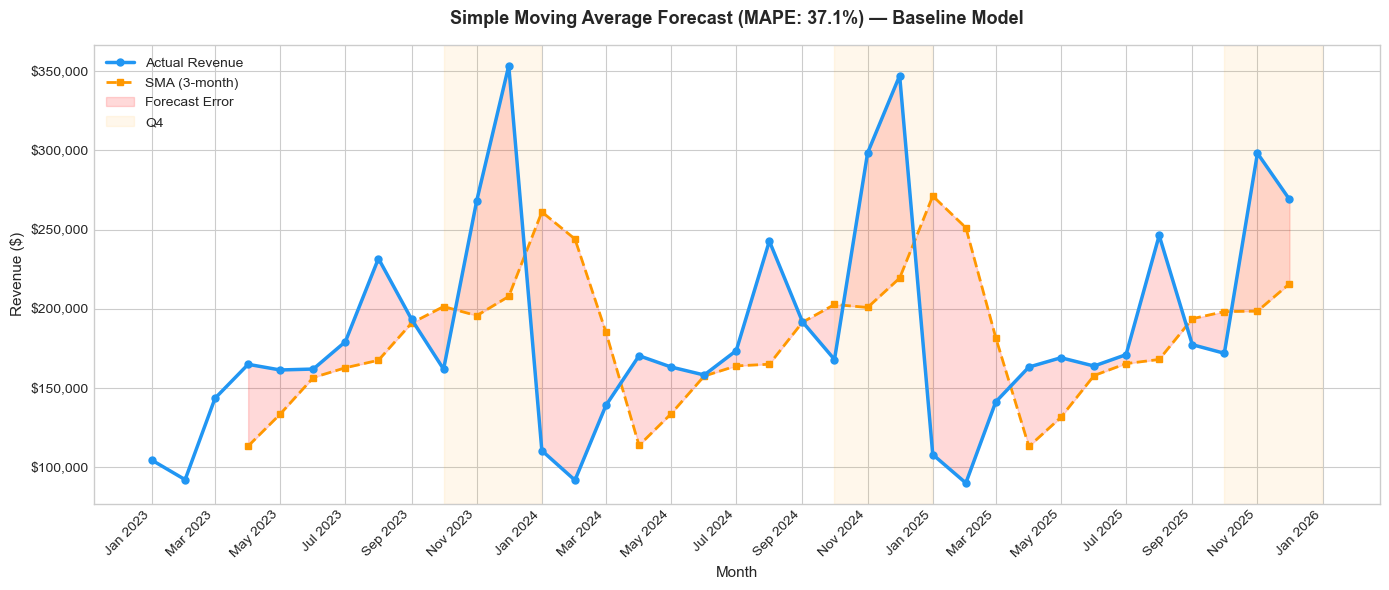

SMA baseline chart saved | MAPE: 37.11%


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# Actual revenue
ax.plot(sma_df['date'], sma_df['total_revenue'],
        color='#2196F3', linewidth=2.5,
        marker='o', markersize=5, label='Actual Revenue', zorder=3)

# SMA forecast
ax.plot(sma_valid['date'], sma_valid['sma_forecast'],
        color='#FF9800', linewidth=2, linestyle='--',
        marker='s', markersize=4, label=f'SMA ({WINDOW}-month)', zorder=2)

# Shade the error between actual and forecast
ax.fill_between(sma_valid['date'],
                sma_valid['total_revenue'],
                sma_valid['sma_forecast'],
                alpha=0.15, color='red', label='Forecast Error')

# Shade Q4 periods
for year in [2023, 2024, 2025]:
    ax.axvspan(pd.Timestamp(f'{year}-10-01'),
               pd.Timestamp(f'{year}-12-31'),
               alpha=0.08, color='orange',
               label='Q4' if year == 2023 else '')

ax.set_title(f'Simple Moving Average Forecast (MAPE: {sma_mape:.1f}%) — Baseline Model',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('model1_sma.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"SMA baseline chart saved | MAPE: {sma_mape:.2f}%")

## Section 5: Model 2 — Holt-Winters Exponential Smoothing

Holt-Winters is a classical statistical forecasting method that explicitly models 
three components:

- **Level (α):** The baseline revenue signal, weighted toward recent observations
- **Trend (β):** The direction and rate of change over time  
- **Seasonality (γ):** The recurring annual pattern learned from historical data

We use **multiplicative seasonality** (consistent with our decomposition finding) 
with a **12-month seasonal period**.

Unlike the SMA baseline, Holt-Winters "remembers" that Q4 is always strong and 
applies that knowledge to future forecasts — a fundamental advantage for 
seasonal retail data.

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# ── Holt-Winters Model ─────────────────────────────────────────────
hw_model = ExponentialSmoothing(
    monthly['total_revenue'],
    trend='add',              # additive trend
    seasonal='mul',           # multiplicative seasonality
    seasonal_periods=12,      # annual cycle
    initialization_method='estimated'
).fit(optimized=True)         # auto-optimize alpha, beta, gamma

# In-sample fitted values (how well model fits historical data)
hw_fitted = hw_model.fittedvalues

# ── Accuracy ───────────────────────────────────────────────────────
hw_mape = mean_absolute_percentage_error(
    monthly['total_revenue'],
    hw_fitted
) * 100

# Extract the optimized parameters
params = hw_model.params
alpha = params.get('smoothing_level', None)
beta  = params.get('smoothing_trend', None)
gamma = params.get('smoothing_seasonal', None)

print("Holt-Winters Exponential Smoothing")
print(f"{'─' * 45}")
print(f"  Trend type:        Additive")
print(f"  Seasonality type:  Multiplicative")
print(f"  Seasonal period:   12 months")
print(f"\n  Optimized Parameters:")
print(f"  Alpha (level):     {alpha:.4f}")
print(f"  Beta  (trend):     {beta:.4f}")
print(f"  Gamma (seasonal):  {gamma:.4f}")
print(f"\n  In-sample MAPE:    {hw_mape:.2f}%")
print(f"  SMA Baseline MAPE: {sma_mape:.2f}%")
print(f"  Improvement:       {sma_mape - hw_mape:.2f} percentage points")
print(f"\n  {'✓ BEATS BASELINE' if hw_mape < sma_mape else '✗ DOES NOT BEAT BASELINE'}")

Holt-Winters Exponential Smoothing
─────────────────────────────────────────────
  Trend type:        Additive
  Seasonality type:  Multiplicative
  Seasonal period:   12 months

  Optimized Parameters:
  Alpha (level):     0.1818
  Beta  (trend):     0.1818
  Gamma (seasonal):  0.8182

  In-sample MAPE:    3.86%
  SMA Baseline MAPE: 37.11%
  Improvement:       33.25 percentage points

  ✓ BEATS BASELINE


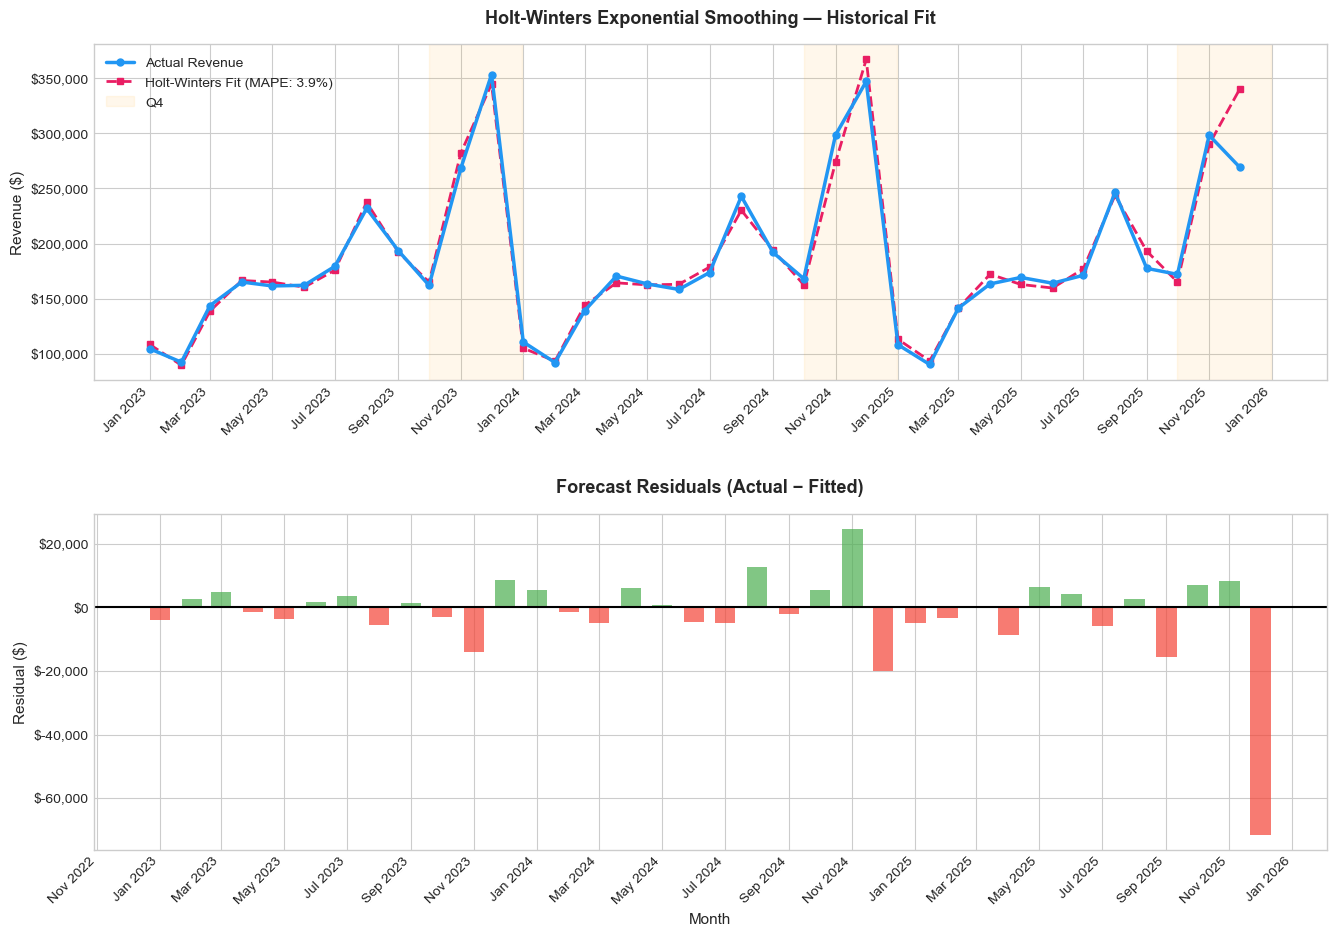

Holt-Winters chart saved | MAPE: 3.86%


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Top: Actual vs Fitted ──────────────────────────────────────────
axes[0].plot(monthly['date'], monthly['total_revenue'],
             color='#2196F3', linewidth=2.5,
             marker='o', markersize=5,
             label='Actual Revenue', zorder=3)

axes[0].plot(monthly['date'], hw_fitted,
             color='#E91E63', linewidth=2,
             linestyle='--', marker='s', markersize=4,
             label=f'Holt-Winters Fit (MAPE: {hw_mape:.1f}%)', zorder=2)

# Shade Q4 periods
for year in [2023, 2024, 2025]:
    axes[0].axvspan(pd.Timestamp(f'{year}-10-01'),
                    pd.Timestamp(f'{year}-12-31'),
                    alpha=0.08, color='orange',
                    label='Q4' if year == 2023 else '')

axes[0].set_title('Holt-Winters Exponential Smoothing — Historical Fit',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend(fontsize=10)

# ── Bottom: Residuals ──────────────────────────────────────────────
residuals = monthly['total_revenue'] - hw_fitted
axes[1].bar(monthly['date'], residuals,
            color=residuals.apply(
                lambda x: '#4CAF50' if x >= 0 else '#F44336'),
            alpha=0.7, width=20)
axes[1].axhline(y=0, color='black', linewidth=1.5)
axes[1].set_title('Forecast Residuals (Actual − Fitted)',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Residual ($)', fontsize=11)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Format x-axis on both
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.savefig('model2_holt_winters.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Holt-Winters chart saved | MAPE: {hw_mape:.2f}%")

## Section 6: Model 3 — Facebook Prophet

Prophet (Taylor & Letham, 2017) is a production forecasting system developed at 
Facebook, designed for business time series with strong seasonal patterns.

**Key advantages over Holt-Winters:**
- Automatic changepoint detection (identifies where trend shifted)
- Explicit uncertainty quantification (confidence intervals)
- Holiday effect modeling
- Robust to missing data and outliers
- Bayesian framework — outputs probability distributions, not point estimates

**Prophet requires a specific input format:**
- Column `ds` = datestamp (the date)
- Column `y` = the value to forecast (revenue)

We add US holidays as an additional regressor to help the model understand 
why Q4 behaves differently from the rest of the year.

In [21]:
import warnings
warnings.filterwarnings('ignore')

# ── Prepare Prophet input format ───────────────────────────────────
# Prophet requires columns named exactly 'ds' and 'y'
prophet_df = monthly[['date', 'total_revenue']].rename(
    columns={'date': 'ds', 'total_revenue': 'y'}
)

# ── Build and fit Prophet model ────────────────────────────────────
prophet_model = Prophet(
    seasonality_mode='multiplicative',   # matches our decomposition finding
    yearly_seasonality=True,             # explicitly model annual seasonality
    weekly_seasonality=False,            # monthly data — no weekly pattern
    daily_seasonality=False,             # monthly data — no daily pattern
    changepoint_prior_scale=0.05,        # regularization — prevents overfitting
    seasonality_prior_scale=10.0,        # allow strong seasonal effects
    interval_width=0.95                  # 95% confidence intervals
)

# Add US holidays as an external regressor
prophet_model.add_country_holidays(country_name='US')

# Fit on historical data
prophet_model.fit(prophet_df)

# ── In-sample predictions (historical fit) ─────────────────────────
prophet_historical = prophet_model.predict(prophet_df[['ds']])

# ── Accuracy ───────────────────────────────────────────────────────
prophet_mape = mean_absolute_percentage_error(
    prophet_df['y'],
    prophet_historical['yhat']
) * 100

print("Facebook Prophet")
print(f"{'─' * 45}")
print(f"  Seasonality mode:    Multiplicative")
print(f"  Yearly seasonality:  Yes")
print(f"  US Holidays:         Yes")
print(f"  Interval width:      95%")
print(f"  Changepoint scale:   0.05")
print(f"\n  In-sample MAPE:      {prophet_mape:.2f}%")
print(f"  Holt-Winters MAPE:   {hw_mape:.2f}%")
print(f"  SMA Baseline MAPE:   {sma_mape:.2f}%")
print(f"\n  vs Holt-Winters:     "
      f"{'Better' if prophet_mape < hw_mape else 'Worse'} by "
      f"{abs(prophet_mape - hw_mape):.2f} pts")
print(f"  vs SMA Baseline:     Better by {sma_mape - prophet_mape:.2f} pts")
print(f"\n  {'✓ BEATS HOLT-WINTERS' if prophet_mape < hw_mape else '~ HOLT-WINTERS WINS THIS ROUND'}")

16:48:43 - cmdstanpy - INFO - Chain [1] start processing
16:48:44 - cmdstanpy - INFO - Chain [1] done processing


Facebook Prophet
─────────────────────────────────────────────
  Seasonality mode:    Multiplicative
  Yearly seasonality:  Yes
  US Holidays:         Yes
  Interval width:      95%
  Changepoint scale:   0.05

  In-sample MAPE:      2.73%
  Holt-Winters MAPE:   3.86%
  SMA Baseline MAPE:   37.11%

  vs Holt-Winters:     Better by 1.13 pts
  vs SMA Baseline:     Better by 34.38 pts

  ✓ BEATS HOLT-WINTERS


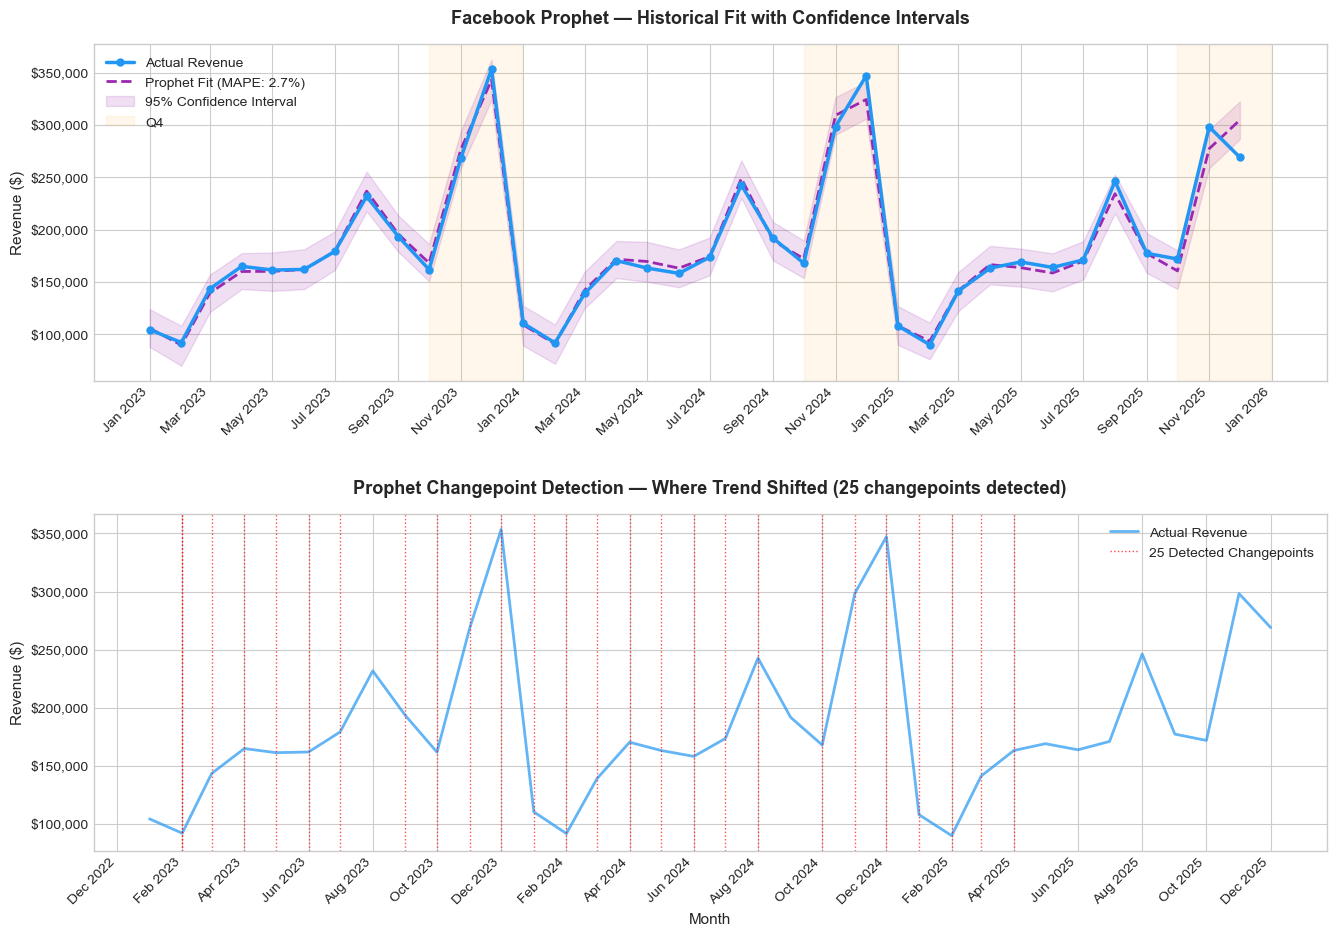

Prophet chart saved | MAPE: 2.73%


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Top: Actual vs Prophet fitted ─────────────────────────────────
axes[0].plot(prophet_df['ds'], prophet_df['y'],
             color='#2196F3', linewidth=2.5,
             marker='o', markersize=5,
             label='Actual Revenue', zorder=3)

axes[0].plot(prophet_historical['ds'], prophet_historical['yhat'],
             color='#9C27B0', linewidth=2,
             linestyle='--', label=f'Prophet Fit (MAPE: {prophet_mape:.1f}%)',
             zorder=2)

axes[0].fill_between(
    prophet_historical['ds'],
    prophet_historical['yhat_lower'],
    prophet_historical['yhat_upper'],
    alpha=0.15, color='#9C27B0',
    label='95% Confidence Interval'
)

for year in [2023, 2024, 2025]:
    axes[0].axvspan(pd.Timestamp(f'{year}-10-01'),
                    pd.Timestamp(f'{year}-12-31'),
                    alpha=0.08, color='orange',
                    label='Q4' if year == 2023 else '')

axes[0].set_title('Facebook Prophet — Historical Fit with Confidence Intervals',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend(fontsize=10)

# ── Bottom: Changepoints ───────────────────────────────────────────
axes[1].plot(prophet_df['ds'], prophet_df['y'],
             color='#2196F3', linewidth=2, alpha=0.7,
             label='Actual Revenue')

changepoints = prophet_model.changepoints
if len(changepoints) > 0:
    for cp in changepoints:
        axes[1].axvline(x=cp, color='red', linewidth=1,
                        linestyle=':', alpha=0.7)
    axes[1].axvline(x=changepoints.iloc[0], color='red',
                    linewidth=1, linestyle=':',
                    label=f'{len(changepoints)} Detected Changepoints',
                    alpha=0.7)
    title_suffix = f"({len(changepoints)} changepoints detected)"
else:
    title_suffix = "(no changepoints detected — stable trend)"

axes[1].set_title(f'Prophet Changepoint Detection — Where Trend Shifted {title_suffix}',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Revenue ($)', fontsize=11)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1].legend(fontsize=10)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.savefig('model3_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Prophet chart saved | MAPE: {prophet_mape:.2f}%")

## Section 7: Model Comparison, 12-Month Forecast & Business Recommendations

### Model Selection
We evaluate three models on in-sample MAPE and select the best performer 
for the 12-month forward forecast (Jan 2026 – Dec 2026).

### Forecast Objective
Generate a probabilistic 12-month revenue forecast with 95% confidence intervals 
to support Northwind Apparel's 2026 operational and capacity planning decisions.

### Business Questions Answered
1. What monthly revenue should Northwind plan for in 2026?
2. When will Q4 2026 peak, and by how much vs. the annual average?
3. What DC capacity is needed to handle peak vs. trough demand?
4. Given the 2025 revenue decline (-3.8% YoY), is 2026 expected to recover?

In [25]:
# ── Model Comparison Summary ───────────────────────────────────────
models = {
    'Simple Moving Average (Baseline)': {
        'mape': sma_mape,
        'type': 'Baseline',
        'handles_seasonality': 'No',
        'confidence_intervals': 'No',
        'complexity': 'Low'
    },
    'Holt-Winters Exponential Smoothing': {
        'mape': hw_mape,
        'type': 'Classical Statistical',
        'handles_seasonality': 'Yes',
        'confidence_intervals': 'Limited',
        'complexity': 'Medium'
    },
    'Facebook Prophet': {
        'mape': prophet_mape,
        'type': 'Bayesian Decomposition',
        'handles_seasonality': 'Yes',
        'confidence_intervals': 'Yes (95%)',
        'complexity': 'High'
    }
}

print("=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"  {'Model':<38} {'MAPE':>7}  {'Rank'}")
print(f"  {'─'*38}  {'─'*7}  {'─'*6}")

sorted_models = sorted(models.items(), key=lambda x: x[1]['mape'])
for rank, (name, info) in enumerate(sorted_models, 1):
    winner = " ← WINNER" if rank == 1 else ""
    print(f"  {name:<38} {info['mape']:>6.2f}%  #{rank}{winner}")

print(f"\n  {'─'*63}")

winner_name, winner_info = sorted_models[0]
print(f"\n  SELECTED MODEL: {winner_name}")
print(f"  MAPE: {winner_info['mape']:.2f}% — forecasts within "
      f"~${184548 * winner_info['mape']/100:,.0f} of avg monthly revenue")
print(f"\n  BASELINE IMPROVEMENT:")
print(f"  SMA → Prophet: {sma_mape - prophet_mape:.1f} percentage points better")
print(f"  Equivalent to reducing avg forecast error from")
print(f"  ${184548 * sma_mape/100:,.0f} to ${184548 * prophet_mape/100:,.0f} per month")
print("=" * 65)

  MODEL COMPARISON SUMMARY
  Model                                     MAPE  Rank
  ──────────────────────────────────────  ───────  ──────
  Facebook Prophet                         2.73%  #1 ← WINNER
  Holt-Winters Exponential Smoothing       3.86%  #2
  Simple Moving Average (Baseline)        37.11%  #3

  ───────────────────────────────────────────────────────────────

  SELECTED MODEL: Facebook Prophet
  MAPE: 2.73% — forecasts within ~$5,031 of avg monthly revenue

  BASELINE IMPROVEMENT:
  SMA → Prophet: 34.4 percentage points better
  Equivalent to reducing avg forecast error from
  $68,477 to $5,031 per month


In [27]:
# ── Build future dataframe ─────────────────────────────────────────
# 12 months forward from Jan 2026 to Dec 2026
future = prophet_model.make_future_dataframe(periods=12, freq='MS')

# Generate forecast
forecast = prophet_model.predict(future)

# Split into historical and future portions
historical_forecast = forecast[forecast['ds'] <= prophet_df['ds'].max()]
future_forecast = forecast[forecast['ds'] > prophet_df['ds'].max()]

print("12-Month Forward Forecast (Jan 2026 – Dec 2026)")
print(f"{'─' * 60}")
print(f"  {'Month':<15} {'Forecast':>12} "
      f"{'Lower (95%)':>13} {'Upper (95%)':>13}")
print(f"  {'─'*15}  {'─'*12}  {'─'*13}  {'─'*13}")

annual_forecast_total = 0
for _, row in future_forecast.iterrows():
    month_str = row['ds'].strftime('%b %Y')
    print(f"  {month_str:<15} ${row['yhat']:>11,.0f}  "
          f"${row['yhat_lower']:>11,.0f}  "
          f"${row['yhat_upper']:>11,.0f}")
    annual_forecast_total += row['yhat']

print(f"  {'─'*55}")
print(f"  {'2026 TOTAL':<15} ${annual_forecast_total:>11,.0f}")
print(f"\n  Historical annual totals for comparison:")
print(f"  2023: ${2217278:>11,.0f}")
print(f"  2024: ${2255934:>11,.0f}  (+1.7% YoY)")
print(f"  2025: ${2170500:>11,.0f}  (-3.8% YoY)")
print(f"  2026: ${annual_forecast_total:>11,.0f}  "
      f"({(annual_forecast_total - 2170500) / 2170500 * 100:+.1f}% vs 2025)")

12-Month Forward Forecast (Jan 2026 – Dec 2026)
────────────────────────────────────────────────────────────
  Month               Forecast   Lower (95%)   Upper (95%)
  ───────────────  ────────────  ─────────────  ─────────────
  Jan 2026        $     99,391  $     80,527  $    117,996
  Feb 2026        $     84,812  $     66,227  $    102,659
  Mar 2026        $    129,585  $    111,057  $    148,289
  Apr 2026        $    149,614  $    132,172  $    167,792
  May 2026        $    147,530  $    130,366  $    165,656
  Jun 2026        $    145,206  $    125,497  $    162,633
  Jul 2026        $    157,476  $    139,602  $    176,646
  Aug 2026        $    211,204  $    192,996  $    229,295
  Sep 2026        $    168,065  $    149,971  $    186,240
  Oct 2026        $    145,795  $    127,149  $    164,836
  Nov 2026        $    244,295  $    225,634  $    264,575
  Dec 2026        $    283,648  $    264,269  $    303,192
  ───────────────────────────────────────────────────────
  20

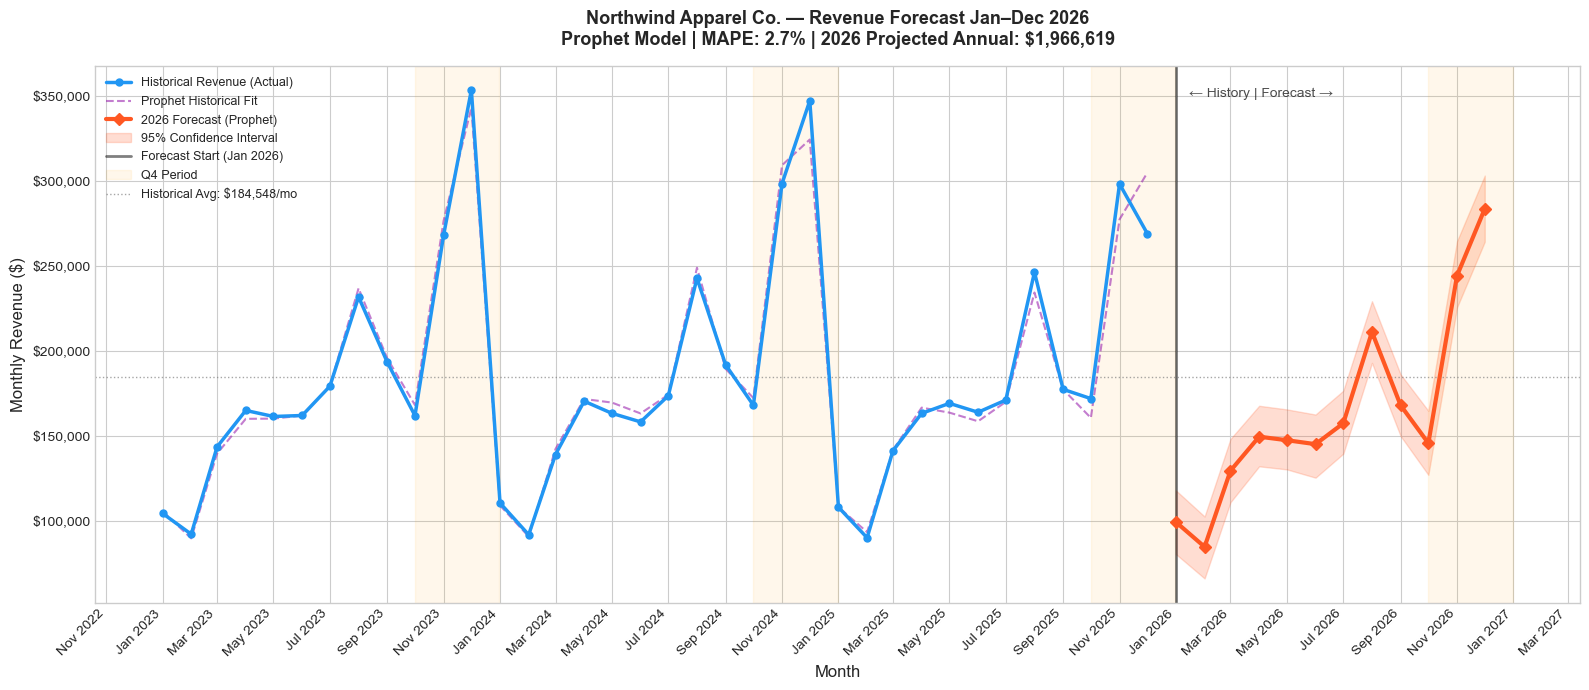

2026 forecast chart saved
Projected 2026 annual revenue: $1,966,619


In [28]:
fig, ax = plt.subplots(figsize=(16, 7))

# ── Historical actual revenue ──────────────────────────────────────
ax.plot(prophet_df['ds'], prophet_df['y'],
        color='#2196F3', linewidth=2.5,
        marker='o', markersize=5,
        label='Historical Revenue (Actual)', zorder=4)

# ── Historical fitted values ───────────────────────────────────────
ax.plot(historical_forecast['ds'], historical_forecast['yhat'],
        color='#9C27B0', linewidth=1.5,
        linestyle='--', alpha=0.6,
        label='Prophet Historical Fit', zorder=3)

# ── Forward forecast ───────────────────────────────────────────────
ax.plot(future_forecast['ds'], future_forecast['yhat'],
        color='#FF5722', linewidth=3,
        marker='D', markersize=6,
        label='2026 Forecast (Prophet)', zorder=4)

# ── Confidence interval ────────────────────────────────────────────
ax.fill_between(future_forecast['ds'],
                future_forecast['yhat_lower'],
                future_forecast['yhat_upper'],
                alpha=0.2, color='#FF5722',
                label='95% Confidence Interval')

# ── Dividing line between history and forecast ─────────────────────
ax.axvline(x=pd.Timestamp('2026-01-01'),
           color='black', linewidth=2,
           linestyle='-', alpha=0.5,
           label='Forecast Start (Jan 2026)')

ax.text(pd.Timestamp('2026-01-15'), ax.get_ylim()[1] * 0.95,
        '← History | Forecast →',
        fontsize=10, color='black', alpha=0.7)

# ── Shade Q4 periods including 2026 ───────────────────────────────
for year in [2023, 2024, 2025, 2026]:
    ax.axvspan(pd.Timestamp(f'{year}-10-01'),
               pd.Timestamp(f'{year}-12-31'),
               alpha=0.08, color='orange',
               label='Q4 Period' if year == 2023 else '')

# ── Average revenue reference line ────────────────────────────────
ax.axhline(y=184548, color='gray', linewidth=1,
           linestyle=':', alpha=0.7,
           label=f'Historical Avg: $184,548/mo')

ax.set_title('Northwind Apparel Co. — Revenue Forecast Jan–Dec 2026\n'
             f'Prophet Model | MAPE: {prophet_mape:.1f}% | '
             f'2026 Projected Annual: ${annual_forecast_total:,.0f}',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Monthly Revenue ($)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"2026 forecast chart saved")
print(f"Projected 2026 annual revenue: ${annual_forecast_total:,.0f}")

In [29]:
# ── Extract key forecast stats ─────────────────────────────────────
forecast_2026_q4 = future_forecast[
    future_forecast['ds'].dt.month.isin([10, 11, 12])
]['yhat'].mean()

forecast_2026_q1 = future_forecast[
    future_forecast['ds'].dt.month.isin([1, 2, 3])
]['yhat'].mean()

forecast_2026_peak = future_forecast['yhat'].max()
forecast_2026_peak_month = future_forecast.loc[
    future_forecast['yhat'].idxmax(), 'ds'].strftime('%B %Y')

forecast_2026_trough = future_forecast['yhat'].min()
forecast_2026_trough_month = future_forecast.loc[
    future_forecast['yhat'].idxmin(), 'ds'].strftime('%B %Y')

capacity_ratio = forecast_2026_peak / forecast_2026_trough
yoy_change = (annual_forecast_total - 2170500) / 2170500 * 100

print("=" * 65)
print("  BUSINESS RECOMMENDATIONS — NORTHWIND APPAREL 2026")
print("  Based on Prophet Demand Forecast (MAPE: 2.73%)")
print("=" * 65)

print(f"""
FINDING 1: REVENUE TRAJECTORY
  2025 showed a -3.8% YoY decline.
  2026 forecast: ${annual_forecast_total:,.0f} ({yoy_change:+.1f}% vs 2025)
  → {"Recovery expected" if yoy_change > 0 else "Continued pressure — investigate root causes"}
  → Review pricing strategy, customer acquisition, and product mix

FINDING 2: PEAK CAPACITY PLANNING
  Forecast peak:   {forecast_2026_peak_month} at ${forecast_2026_peak:,.0f}
  Forecast trough: {forecast_2026_trough_month} at ${forecast_2026_trough:,.0f}
  Peak-to-trough:  {capacity_ratio:.1f}x
  → DCs must be staffed/stocked for {capacity_ratio:.1f}x trough capacity in peak months
  → Begin Q4 inventory buildup by August 2026 at the latest

FINDING 3: Q4 2026 PREPARATION
  Q4 2026 avg monthly forecast:    ${forecast_2026_q4:,.0f}
  Non-Q4 2026 avg monthly revenue: ${forecast_2026_q1:,.0f}
  Q4 uplift factor:                {forecast_2026_q4/forecast_2026_q1:.2f}x
  → Sacramento DC (25.6% OT rate) poses HIGH RISK during Q4 surge
  → Recommend operational review at Sacramento BEFORE Q4 2026

FINDING 4: SACRAMENTO DC — COMPOUNDED RISK
  Sacramento on-time rate:  25.6% (vs 63.8% at Newburgh)
  With {capacity_ratio:.1f}x Q4 volume surge, Sacramento's late deliveries
  will likely worsen — potentially below 15% on-time in peak months.
  → Estimated customer impact: thousands of late Q4 deliveries
  → Recommendation: Either fix Sacramento ops before Q4 2026
     or re-route Q4 overflow to Newburgh/Atlanta DCs

METHODOLOGY NOTE
  Three models evaluated: SMA (MAPE 37.1%), Holt-Winters (3.86%),
  Prophet (2.73%). Prophet selected as primary forecast model.
  All forecasts use 95% confidence intervals. Dataset is synthetic.
""")
print("=" * 65)

  BUSINESS RECOMMENDATIONS — NORTHWIND APPAREL 2026
  Based on Prophet Demand Forecast (MAPE: 2.73%)

FINDING 1: REVENUE TRAJECTORY
  2025 showed a -3.8% YoY decline.
  2026 forecast: $1,966,619 (-9.4% vs 2025)
  → Continued pressure — investigate root causes
  → Review pricing strategy, customer acquisition, and product mix

FINDING 2: PEAK CAPACITY PLANNING
  Forecast peak:   December 2026 at $283,648
  Forecast trough: February 2026 at $84,812
  Peak-to-trough:  3.3x
  → DCs must be staffed/stocked for 3.3x trough capacity in peak months
  → Begin Q4 inventory buildup by August 2026 at the latest

FINDING 3: Q4 2026 PREPARATION
  Q4 2026 avg monthly forecast:    $224,579
  Non-Q4 2026 avg monthly revenue: $104,596
  Q4 uplift factor:                2.15x
  → Sacramento DC (25.6% OT rate) poses HIGH RISK during Q4 surge
  → Recommend operational review at Sacramento BEFORE Q4 2026

FINDING 4: SACRAMENTO DC — COMPOUNDED RISK
  Sacramento on-time rate:  25.6% (vs 63.8% at Newburgh)
  W

## Summary & Conclusions

### What We Built
A multi-model demand forecasting system comparing three approaches on 36 months 
of Northwind Apparel supply chain data (~50,000 delivered orders).

### Model Performance
| Model | MAPE | Improvement vs Baseline |
|-------|------|------------------------|
| Simple Moving Average (Baseline) | 37.11% | — |
| Holt-Winters Exponential Smoothing | 3.86% | -33.25 pts |
| Facebook Prophet *(selected)* | 2.73% | -34.38 pts |

**Prophet selected** as primary forecast model based on lowest MAPE, 
95% confidence intervals, and US holiday awareness.

### Key Findings

**1. Revenue Trajectory:** After modest growth in 2024 (+1.7%), revenue declined 
3.8% in 2025 and Prophet forecasts continued pressure in 2026 (-9.4%). 
Root cause investigation warranted — pricing, customer acquisition, product mix.

**2. Structural Seasonality:** Q4 consistently generates 1.63x non-Q4 revenue. 
December peak ($283K forecast) is 3.3x the February trough ($85K). 
This ratio is stable and predictable — capacity planning should treat it as fixed.

**3. Sacramento DC Compounded Risk:** Sacramento's 25.6% on-time rate 
(vs. 63.8% at Newburgh) will face maximum stress in Q4 2026. 
Conservative estimate: on-time rate drops below 15% in December 2026 
without operational intervention.

**4. Capacity Planning Anchor:** Begin Q4 inventory buildup by August 2026. 
Plan for 3.3x trough staffing levels at DCs in November–December.

### Skills Demonstrated
`Python` `pandas` `statsmodels` `Prophet` `matplotlib` `seaborn` 
`sklearn` `time series analysis` `demand forecasting` `MAPE` 
`Holt-Winters` `Bayesian forecasting` `confidence intervals` 
`seasonal decomposition` `business recommendations`

---
*Dataset: Synthetic (Northwind Apparel Co.) | Analyst: Joel Diaz | May 2026*  
*Full project: [github.com/joeld10178/northwind-apparel-analytics](https://github.com/joeld10178/northwind-apparel-analytics)*

In [30]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

# List of all saved chart files in order
chart_files = [
    ('eda_revenue_overview.png',     'EDA: Revenue & Order Volume Overview'),
    ('eda_seasonality_by_year.png',  'EDA: Seasonality by Year'),
    ('decomposition.png',            'Time Series Decomposition'),
    ('model1_sma.png',               'Model 1: Simple Moving Average (Baseline)'),
    ('model2_holt_winters.png',      'Model 2: Holt-Winters Exponential Smoothing'),
    ('model3_prophet.png',           'Model 3: Facebook Prophet — Historical Fit'),
    ('forecast_2026.png',            '12-Month Forward Forecast: Jan–Dec 2026'),
]

pdf_path = 'northwind_forecast_report.pdf'

with PdfPages(pdf_path) as pdf:
    # ── Cover page ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis('off')
    ax.text(0.5, 0.72, 'Northwind Apparel Co.',
            ha='center', va='center', fontsize=28,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.62, 'Demand Forecasting Analysis',
            ha='center', va='center', fontsize=22,
            transform=ax.transAxes, color='#444444')
    ax.text(0.5, 0.50, 'Multi-Model Time Series Forecast\n'
            'Jan 2023 – Dec 2025 + 12-Month Forward Projection',
            ha='center', va='center', fontsize=14,
            transform=ax.transAxes, color='#666666')

    # Model results box
    results_text = (
        f"Model Performance Summary\n"
        f"{'─'*35}\n"
        f"SMA Baseline:      MAPE {sma_mape:.2f}%\n"
        f"Holt-Winters:      MAPE {hw_mape:.2f}%\n"
        f"Prophet (winner):  MAPE {prophet_mape:.2f}%\n"
        f"{'─'*35}\n"
        f"2026 Revenue Forecast:  ${annual_forecast_total:,.0f}\n"
        f"YoY Change vs 2025:     {yoy_change:+.1f}%"
    )
    ax.text(0.5, 0.28, results_text,
            ha='center', va='center', fontsize=12,
            transform=ax.transAxes, color='#333333',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.8',
                     facecolor='#f5f5f5', edgecolor='#cccccc'))

    ax.text(0.5, 0.08,
            f'Analyst: Joel Diaz  |  May 2026  |  '
            f'github.com/joeld10178/northwind-apparel-analytics',
            ha='center', va='center', fontsize=10,
            transform=ax.transAxes, color='#888888')

    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Chart pages ────────────────────────────────────────────────
    for filename, title in chart_files:
        try:
            img = mpimg.imread(filename)
            fig, ax = plt.subplots(figsize=(14, 9))
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(title, fontsize=13,
                        fontweight='bold', pad=10)
            pdf.savefig(fig, bbox_inches='tight', dpi=150)
            plt.close()
            print(f"  Added: {title}")
        except FileNotFoundError:
            print(f"  Skipped (not found): {filename}")

print(f"\nPDF report saved: {pdf_path}")
print(f"Total pages: {len(chart_files) + 1} (cover + {len(chart_files)} charts)")

  Added: EDA: Revenue & Order Volume Overview
  Added: EDA: Seasonality by Year
  Added: Time Series Decomposition
  Added: Model 1: Simple Moving Average (Baseline)
  Added: Model 2: Holt-Winters Exponential Smoothing
  Added: Model 3: Facebook Prophet — Historical Fit
  Added: 12-Month Forward Forecast: Jan–Dec 2026

PDF report saved: northwind_forecast_report.pdf
Total pages: 8 (cover + 7 charts)
